## Network Anomaly Detection System
### Objective: Detect potential security threats in cloud LMS network traffic

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score
)

### 2: Load Dataset

In [47]:
print('=' * 60)
print('MEMBER 4: Network Anomaly Detection System')
print('=' * 60)

# NOTE: Place the CSV file in the same folder as this notebook
df = pd.read_csv('Network Traffic Data for Intrusion Detection.csv')

print(f'\n[1] Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

MEMBER 4: Network Anomaly Detection System

[1] Dataset loaded: 2000 rows, 9 columns
Columns: ['Duration', 'Protocol', 'SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort', 'PacketCount', 'ByteCount', 'Label']


### 3: Inspect and Understand Labels

In [48]:
print('\n[2] Label distribution (ground truth — withheld from training):')
print(df['Label'].value_counts())

attack_count = (df['Label'] == 'Attack').sum()
normal_count = (df['Label'] == 'Normal').sum()
total = len(df)
print(f'\nAttack proportion : {attack_count/total:.3f} ({attack_count} records)')
print(f'Normal proportion : {normal_count/total:.3f} ({normal_count} records)')
print('\nNote: Near-equal class distribution (51/49) means models must be trained')
print('on normal records ONLY to establish a clean baseline for anomaly detection.')

# Encode ground truth for post-hoc evaluation ONLY — never used in training
label_map = {'Normal': 1, 'Attack': -1}
y_true = df['Label'].map(label_map).values


[2] Label distribution (ground truth — withheld from training):
Label
Attack    1022
Normal     978
Name: count, dtype: int64

Attack proportion : 0.511 (1022 records)
Normal proportion : 0.489 (978 records)

Note: Near-equal class distribution (51/49) means models must be trained
on normal records ONLY to establish a clean baseline for anomaly detection.


### 4: Preprocessing

In [49]:
# Drop IP addresses — high cardinality, not generalisable
df.drop(columns=['SourceIP', 'DestinationIP'], inplace=True, errors='ignore')

# One-hot encode Protocol
df = pd.get_dummies(df, columns=['Protocol'], drop_first=True)

# Drop Label — withheld from training, used only for post-hoc evaluation
df.drop(columns=['Label'], inplace=True, errors='ignore')

print(f'[3] Features after preprocessing: {list(df.columns)}')

[3] Features after preprocessing: ['Duration', 'SourcePort', 'DestinationPort', 'PacketCount', 'ByteCount', 'Protocol_TCP', 'Protocol_UDP']


### 5: Feature Engineering

In [50]:
# Original features from preprocessing
df['bytes_per_packet'] = df['ByteCount'] / (df['PacketCount'] + 1e-9)
df['high_source_port'] = (df['SourcePort'] > 1024).astype(int)

# Additional engineered features
df['packet_rate']   = df['PacketCount'] / (df['Duration'] + 1e-9)  # packets per second
df['byte_rate']     = df['ByteCount']   / (df['Duration'] + 1e-9)  # bytes per second
df['low_dest_port'] = (df['DestinationPort'] <= 1024).astype(int)  # well-known service ports

print('[4] Feature engineering complete. Features added:')
print('     bytes_per_packet  — data volume per connection unit')
print('     high_source_port  — ephemeral port indicator (>1024)')
print('     packet_rate       — packet transmission rate')
print('     byte_rate         — byte transmission rate')
print('     low_dest_port     — well-known service port indicator (<=1024)')

# Impute and scale
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\n[5] Final feature matrix: {X_scaled.shape[0]} samples x {X_scaled.shape[1]} features')

# Separate normal records for training — core methodological decision
X_train_normal = X_scaled[y_true == 1]
print(f'[6] Normal-only training set: {X_train_normal.shape[0]} records')
print(f'    (Attack records withheld entirely from model fitting)')

[4] Feature engineering complete. Features added:
     bytes_per_packet  — data volume per connection unit
     high_source_port  — ephemeral port indicator (>1024)
     packet_rate       — packet transmission rate
     byte_rate         — byte transmission rate
     low_dest_port     — well-known service port indicator (<=1024)

[5] Final feature matrix: 2000 samples x 12 features
[6] Normal-only training set: 978 records
    (Attack records withheld entirely from model fitting)


### 6: Sensitivity Analysis - Contamination Parameter


[7] Sensitivity Analysis — contamination range 0.30 to 0.499
  Contamination | Flagged | Precision |  Recall |     F1
-------------------------------------------------------
            0.3 |     666 |    0.5586 |  0.3640 | 0.4408
           0.35 |     768 |    0.5547 |  0.4168 | 0.4760
            0.4 |     849 |    0.5395 |  0.4481 | 0.4896
           0.45 |     935 |    0.5294 |  0.4843 | 0.5059
          0.499 |    1029 |    0.5258 |  0.5294 | 0.5275

[8] Best contamination: 0.499 (F1 = 0.5275)


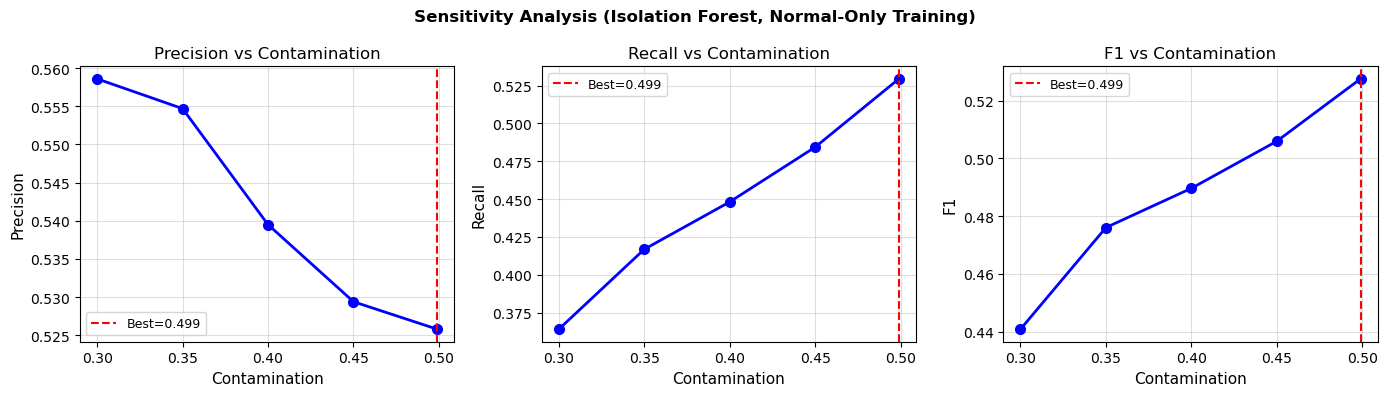

In [51]:
print('\n[7] Sensitivity Analysis — contamination range 0.30 to 0.499')
print(f'{"Contamination":>15} | {"Flagged":>7} | {"Precision":>9} | {"Recall":>7} | {"F1":>6}')
print('-' * 55)

contamination_values = [0.30, 0.35, 0.40, 0.45, 0.499]
sensitivity_results = []

for cont in contamination_values:
    iso = IsolationForest(n_estimators=300, contamination=cont,
                          max_samples='auto', random_state=42)
    iso.fit(X_train_normal)          # ← trained on normal records only
    y_pred = iso.predict(X_scaled)   # ← evaluated on full dataset

    prec = precision_score(y_true, y_pred, pos_label=-1, zero_division=0)
    rec  = recall_score(y_true, y_pred, pos_label=-1, zero_division=0)
    f1   = f1_score(y_true, y_pred, pos_label=-1, zero_division=0)
    n_flagged = (y_pred == -1).sum()

    sensitivity_results.append({
        'Contamination': cont, 'Flagged': n_flagged,
        'Precision': round(prec, 4), 'Recall': round(rec, 4), 'F1': round(f1, 4)
    })
    print(f'{cont:>15} | {n_flagged:>7} | {prec:>9.4f} | {rec:>7.4f} | {f1:>6.4f}')

sens_df = pd.DataFrame(sensitivity_results)
best_cont = sens_df.loc[sens_df['F1'].idxmax(), 'Contamination']
print(f'\n[8] Best contamination: {best_cont} (F1 = {sens_df["F1"].max():.4f})')

# Plot sensitivity analysis
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    ax.plot(sens_df['Contamination'], sens_df[metric], 'bo-', linewidth=2, markersize=7)
    ax.axvline(best_cont, color='red', linestyle='--', linewidth=1.5,
               label=f'Best={best_cont}')
    ax.set_xlabel('Contamination', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} vs Contamination', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)
plt.suptitle('Sensitivity Analysis (Isolation Forest, Normal-Only Training)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

### 7: Final Isolation Forest Model

In [52]:
print(f'\n[9] Fitting final Isolation Forest (contamination={best_cont}, normal-only training)...')

iso_final = IsolationForest(
    n_estimators=300,
    contamination=best_cont,
    max_samples='auto',
    random_state=42
)
iso_final.fit(X_train_normal)             # ← trained on normal records only
y_pred_iso = iso_final.predict(X_scaled)  # ← evaluated on full dataset
anomaly_scores_iso = iso_final.decision_function(X_scaled)

prec_iso     = precision_score(y_true, y_pred_iso, pos_label=-1, zero_division=0)
rec_iso      = recall_score(y_true, y_pred_iso, pos_label=-1, zero_division=0)
f1_iso       = f1_score(y_true, y_pred_iso, pos_label=-1, zero_division=0)
n_flagged_iso = (y_pred_iso == -1).sum()

print(f'  Anomalies flagged : {n_flagged_iso} / {len(y_pred_iso)}')
print(f'  Precision         : {prec_iso:.4f}')
print(f'  Recall            : {rec_iso:.4f}')
print(f'  F1 Score          : {f1_iso:.4f}')


[9] Fitting final Isolation Forest (contamination=0.499, normal-only training)...
  Anomalies flagged : 1029 / 2000
  Precision         : 0.5258
  Recall            : 0.5294
  F1 Score          : 0.5275


### 8: One-Class SVM (Comparative Model)

In [53]:
print(f'\n[10] Fitting One-Class SVM (nu={best_cont}, normal-only training)...')

ocsvm = OneClassSVM(kernel='rbf', nu=best_cont, gamma='scale')
ocsvm.fit(X_train_normal)             # ← trained on normal records only
y_pred_svm = ocsvm.predict(X_scaled)  # ← evaluated on full dataset

prec_svm      = precision_score(y_true, y_pred_svm, pos_label=-1, zero_division=0)
rec_svm       = recall_score(y_true, y_pred_svm, pos_label=-1, zero_division=0)
f1_svm        = f1_score(y_true, y_pred_svm, pos_label=-1, zero_division=0)
n_flagged_svm = (y_pred_svm == -1).sum()

print(f'  Anomalies flagged : {n_flagged_svm} / {len(y_pred_svm)}')
print(f'  Precision         : {prec_svm:.4f}')
print(f'  Recall            : {rec_svm:.4f}')
print(f'  F1 Score          : {f1_svm:.4f}')


[10] Fitting One-Class SVM (nu=0.499, normal-only training)...
  Anomalies flagged : 1018 / 2000
  Precision         : 0.5216
  Recall            : 0.5196
  F1 Score          : 0.5206


### 9: Confusion Matrices

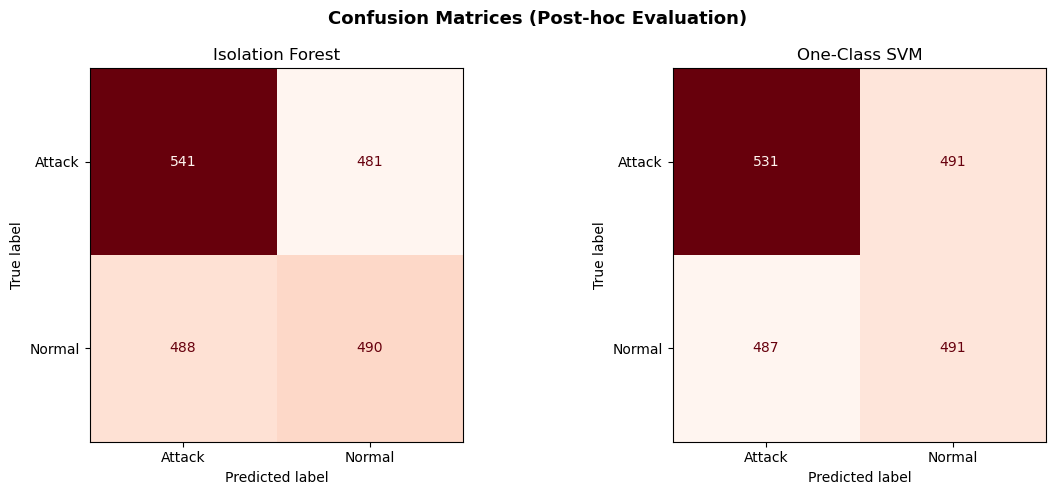

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [
    ('Isolation Forest', y_pred_iso),
    ('One-Class SVM',    y_pred_svm)
]):
    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Attack', 'Normal'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(f'{name}', fontsize=12)

plt.suptitle('Confusion Matrices (Post-hoc Evaluation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

### 10: Anomaly Score Distribution

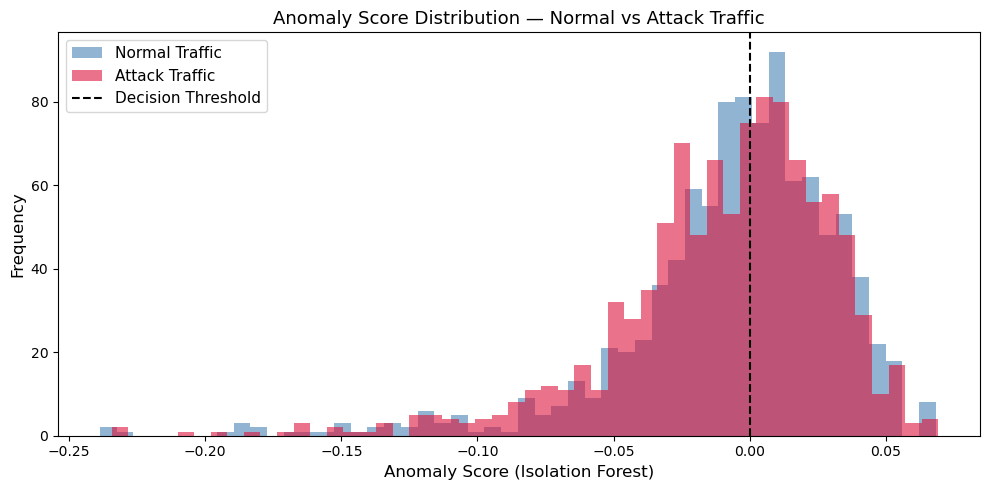

In [55]:
scores_normal = anomaly_scores_iso[y_true == 1]
scores_attack = anomaly_scores_iso[y_true == -1]

plt.figure(figsize=(10, 5))
plt.hist(scores_normal, bins=50, alpha=0.6, color='steelblue', label='Normal Traffic')
plt.hist(scores_attack, bins=50, alpha=0.6, color='crimson',   label='Attack Traffic')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Decision Threshold')
plt.xlabel('Anomaly Score (Isolation Forest)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Anomaly Score Distribution — Normal vs Attack Traffic', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

### 11: PCA Visualisation - Anomaly Map

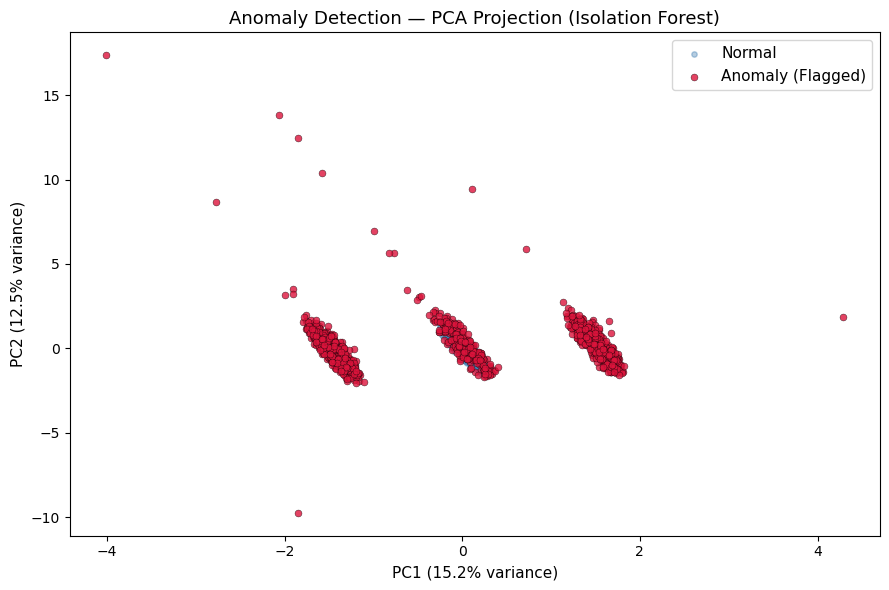

In [56]:
pca = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(9, 6))
normal_mask  = y_pred_iso == 1
anomaly_mask = y_pred_iso == -1
plt.scatter(X_pca[normal_mask, 0],  X_pca[normal_mask, 1],
            c='steelblue', alpha=0.4, s=15, label='Normal')
plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
            c='crimson', alpha=0.8, s=25, label='Anomaly (Flagged)',
            edgecolors='k', linewidths=0.3)
plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=11)
plt.title('Anomaly Detection — PCA Projection (Isolation Forest)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
plt.close()

### 12: Model Comparison Bar Chart

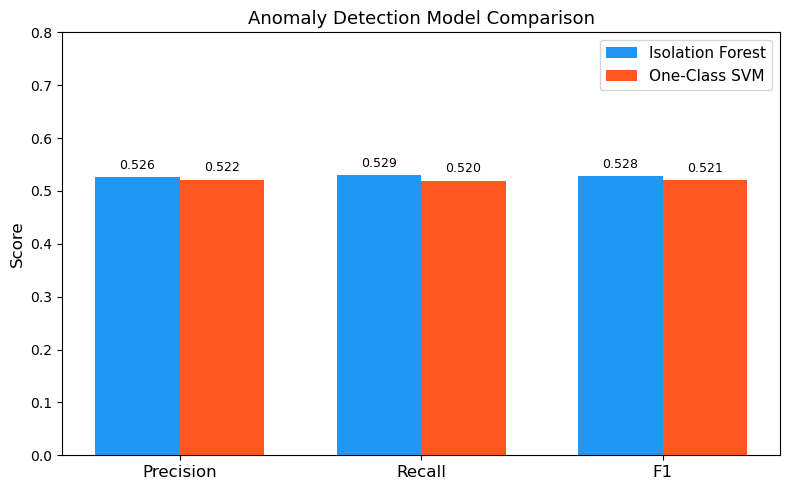

In [57]:
metrics   = ['Precision', 'Recall', 'F1']
iso_vals  = [prec_iso,  rec_iso,  f1_iso]
svm_vals  = [prec_svm,  rec_svm,  f1_svm]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, iso_vals, width, label='Isolation Forest', color='#2196F3')
bars2 = ax.bar(x + width/2, svm_vals, width, label='One-Class SVM',    color='#FF5722')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Anomaly Detection Model Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 0.8)
ax.legend(fontsize=11)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
plt.close()

### 13: Full Classification Reports

In [58]:
print('\n[11] Classification Report — Isolation Forest:')
print(classification_report(y_true, y_pred_iso, target_names=['Attack', 'Normal']))

print('[12] Classification Report — One-Class SVM:')
print(classification_report(y_true, y_pred_svm, target_names=['Attack', 'Normal']))


[11] Classification Report — Isolation Forest:
              precision    recall  f1-score   support

      Attack       0.53      0.53      0.53      1022
      Normal       0.50      0.50      0.50       978

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000

[12] Classification Report — One-Class SVM:
              precision    recall  f1-score   support

      Attack       0.52      0.52      0.52      1022
      Normal       0.50      0.50      0.50       978

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



### 14: Results Summary

In [61]:
print('\n' + '=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset              : Network Traffic Data for Intrusion Detection')
print(f'Total records        : {len(y_true)}')
print(f'Normal training set  : {X_train_normal.shape[0]} records (normal-only)')
print(f'Optimal contamination: {best_cont}')
print()

summary = pd.DataFrame({
    'Model':              ['Isolation Forest', 'One-Class SVM'],
    'Training approach':  ['Normal-only',      'Normal-only'],
    'Contamination/Nu':   [best_cont,           best_cont],
    'Anomalies Flagged':  [n_flagged_iso,        n_flagged_svm],
    'Precision':          [round(prec_iso, 4),   round(prec_svm, 4)],
    'Recall':             [round(rec_iso,  4),   round(rec_svm,  4)],
    'F1 Score':           [round(f1_iso,   4),   round(f1_svm,   4)]
})
print(summary.to_string(index=False))


RESULTS SUMMARY
Dataset              : Network Traffic Data for Intrusion Detection
Total records        : 2000
Normal training set  : 978 records (normal-only)
Optimal contamination: 0.499

           Model Training approach  Contamination/Nu  Anomalies Flagged  Precision  Recall  F1 Score
Isolation Forest       Normal-only             0.499               1029     0.5258  0.5294    0.5275
   One-Class SVM       Normal-only             0.499               1018     0.5216  0.5196    0.5206
